# 01. Bias Detection in Machine Learning Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Detect bias in datasets and model outputs
- Use metrics and visualizations to assess fairness
- Identify sources of discriminatory impact

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

# 01. Bias Detection in Machine Learning Models

## 🚨 THE PROBLEM: AI Systems Are Making Unfair Decisions

**Remember the COMPAS case study from Unit 1?**

We discovered that COMPAS showed:
- Higher false positive rates for Black defendants
- Higher false negative rates for White defendants
- Racial bias in risk predictions

**The Problem**: We understand ethics foundations, but **AI systems show bias. How do we detect it?**

**We've learned:**
- ✅ How to identify ethical issues (frameworks from Unit 1)
- ✅ How bias manifests in real systems (COMPAS case study)
- ✅ That bias is a serious ethical problem

**But we haven't learned:**
- ❌ How to **detect** bias in AI systems
- ❌ How to **measure** bias quantitatively
- ❌ How to **identify** where bias exists

**We need bias detection tools** to:
1. Find where bias exists in our models
2. Measure how unfair our systems are
3. Identify which groups are being discriminated against

**This notebook solves that problem** by teaching you bias detection metrics and tools!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Unit 1: Foundations of AI Ethics** - You need to understand ethical frameworks and case studies!
- ✅ **Basic Python knowledge**: Functions, dictionaries, data manipulation
- ✅ **Basic ML knowledge**: Classification, train/test split, confusion matrices
- ✅ **Understanding of bias**: What is algorithmic bias? (from Unit 1 case studies)

**If you haven't completed these**, you might struggle with:
- Understanding why bias detection matters
- Knowing which metrics to use for bias detection
- Interpreting bias detection results

---

## 🔗 Where This Notebook Fits

**This is the FIRST example in Unit 2** - it addresses the problem from Unit 1!

**Why this example FIRST?**
- **Before** you can mitigate bias, you need to detect it (addresses the problem!)
- **Before** you can ensure fairness, you need to measure it
- **Before** you can fix problems, you need to identify them

**Builds on**: 
- 📓 Unit 1: Foundations (we identified bias as a problem - now we learn to detect it!)

**Leads to**: 
- 📓 Example 2: Bias Mitigation (once we detect bias, we learn to fix it!)
- 📓 Example 3: Fair Representation (ensuring fair representation in data)
- 📓 Example 4: Bias Case Studies (analyzing real bias cases)
- 📓 Example 5: Fair AI Development (building fair AI systems)

**Why this order?**
1. Detection **addresses the problem** from Unit 1 (we need to detect bias!)
2. Detection provides **measurement tools** (needed before mitigation)
3. Detection teaches **what bias looks like** (critical for understanding)

---

## The Story: Finding the Problem Before Fixing It

Imagine you're a doctor diagnosing a patient. **Before** you can treat an illness, you need to diagnose it - run tests, check symptoms, identify the problem. **After** diagnosis, you can prescribe the right treatment!

Same with AI bias: **Before** we can fix bias, we need to detect it - measure fairness metrics, check for disparities, identify where bias exists. **After** detection, we can apply the right mitigation strategies!

---

## Why Bias Detection Matters

Bias detection is essential for ethical AI:
- **Identify Problems**: Find where bias exists in your models
- **Measure Fairness**: Quantify how fair (or unfair) your system is
- **Track Progress**: Monitor if bias mitigation efforts are working
- **Ensure Compliance**: Meet fairness requirements and regulations
- **Build Trust**: Demonstrate commitment to fairness

## Learning Objectives
1. Understand different types of bias in ML models
2. Learn fairness metrics (demographic parity, equalized odds)
3. Detect bias using statistical measures
4. Visualize bias in model predictions
5. Interpret bias detection results
6. Understand when to use different fairness metrics

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us detect bias in machine learning models

import matplotlib.pyplot as plt  # For creating visualizations: Charts, graphs, bias visualizations
import numpy as np  # For numerical operations: Arrays, calculations, random number generation
import pandas as pd  # For data manipulation: DataFrames, data analysis
from sklearn.model_selection import train_test_split  # For splitting data: Separate training and testing sets
from sklearn.ensemble import RandomForestClassifier  # For ML model: Classification algorithm
from sklearn.metrics import confusion_matrix, classification_report  # For model evaluation: Performance metrics
import seaborn as sns  # For statistical visualizations: Heatmaps, advanced plots
import os  # For file operations: Saving images

# Configure matplotlib settings: Set default figure size and font size for better visualizations
plt.rcParams['font.size'] = 10  # Font size: Make text readable (10pt is good for most displays)
plt.rcParams['figure.figsize'] = (14, 8)  # Figure size: 14 inches wide, 8 inches tall (good for detailed charts)

print(" Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - matplotlib/seaborn: Create visualizations (bias charts, heatmaps)")
print("   - numpy: Numerical operations (arrays, calculations)")
print("   - pandas: Data manipulation (DataFrames, analysis)")
print("   - sklearn: Machine learning (models, metrics, data splitting)")
print("   - os: File operations (saving images)")


 Libraries imported successfully!

📚 What each library does:
   - matplotlib/seaborn: Create visualizations (bias charts, heatmaps)
   - numpy: Numerical operations (arrays, calculations)
   - pandas: Data manipulation (DataFrames, analysis)
   - sklearn: Machine learning (models, metrics, data splitting)
   - os: File operations (saving images)


## Part 2: Understanding Bias in Data

### 📚 Prerequisites (What You Need First)
- **Library imports** (from Part 1) - Understanding data manipulation and ML tools
- **Understanding of bias** (from Unit 1) - Knowing what bias is

### 🔗 Relationship: What This Builds On
This creates data with intentional bias so we can practice detecting it!
- Builds on: Data manipulation skills, understanding of bias
- Shows: How bias manifests in data

### 📖 The Story
**Before biased data**: We need data with known bias to practice detection.
**After biased data**: We have a dataset where we know bias exists, so we can test our detection methods!

In [2]:
# Step 2: Generate synthetic hiring data with intentional bias
# This creates a dataset where we KNOW bias exists, so we can practice detecting it

print("\n" + "="*80)
print("📊 GENERATING SYNTHETIC DATA WITH KNOWN BIAS")
print("="*80)

def generate_biased_data(n_samples=2000):
    """
    Generate a synthetic hiring dataset with built-in bias against Group B.

    HOW IT WORKS:
    1. Creates two groups (A and B) with the SAME skill distribution
    2. Base hiring probability depends only on qualifications
    3. Group B gets an unfair penalty (-0.20) on hiring probability
    4. So any hiring gap between groups is pure bias, not skill
    """
    np.random.seed(42)
    group = np.random.choice(['Group A', 'Group B'], n_samples, p=[0.5, 0.5])
    age = np.random.randint(22, 60, n_samples)
    experience_years = np.random.randint(0, 20, n_samples)
    education_level = np.random.choice([1, 2, 3, 4], n_samples)
    skill_score = np.random.normal(70, 15, n_samples)

    # Base probability: qualifications only (identical process for both groups)
    base_prob = (skill_score / 100 + experience_years / 20 + education_level / 4) / 3
    # Inject bias: Group B is penalized regardless of qualifications
    bias_penalty = np.where(group == 'Group B', -0.20, 0.0)
    prob = np.clip(base_prob + bias_penalty + np.random.normal(0, 0.05, n_samples), 0, 1)
    hired = (prob > 0.5).astype(int)

    return pd.DataFrame({'group': group, 'age': age,
                         'experience_years': experience_years,
                         'education_level': education_level,
                         'skill_score': skill_score, 'hired': hired})

df = generate_biased_data(n_samples=2000)
print(f"Generated dataset with {len(df)} samples")
print("\nHiring rates by group (ground truth in the data):")
for group in ['Group A', 'Group B']:
    rate = df[df['group'] == group]['hired'].mean()
    print(f"  {group}: {rate:.3f} ({rate*100:.1f}%)")
print("\nSkill scores by group (nearly identical - the gap above is BIAS):")
print(df.groupby('group')['skill_score'].mean().round(2).to_string())



📊 GENERATING SYNTHETIC DATA WITH KNOWN BIAS
Generated dataset with 2000 samples

Hiring rates by group (ground truth in the data):
  Group A: 0.763 (76.3%)
  Group B: 0.259 (25.9%)

Skill scores by group (nearly identical - the gap above is BIAS):
group
Group A    70.29
Group B    70.32


## Part 3: Detecting Bias with Fairness Metrics

### 📚 Prerequisites (What You Need First)
-  **Biased data generated** (from Part 2) - Understanding the dataset with known bias
-  **Understanding of fairness** - Knowing what fairness means

### 🔗 Relationship: What This Builds On
This is where we actually detect the bias we created!
- Builds on: Biased dataset, understanding of fairness metrics
- Shows: How to measure and detect bias

### 📖 The Story
**Before detection**: We have biased data but don't know how to measure it.
**After detection**: We can quantify bias using fairness metrics and see exactly where it exists!

---

## Step 3: Calculate Fairness Metrics

**BEFORE**: We have data but don't know how to measure bias.

**AFTER**: We'll calculate fairness metrics (demographic parity, equalized odds) to detect bias!

**Why fairness metrics?** They provide:
- Quantitative measures of bias
- Standard ways to compare groups
- Clear thresholds for what's "fair"

In [3]:
# Step 3: Define fairness metric functions
# These quantify bias: demographic parity and equalized odds

def calculate_demographic_parity(test_df):
    """
    Demographic parity: does each group receive positive predictions at the
    same rate?  Returns per-group positive prediction rates and the disparity
    (max rate - min rate).  A disparity above ~0.1 is a common warning sign.
    """
    rates = test_df.groupby('group')['predicted'].mean().to_dict()
    disparity = max(rates.values()) - min(rates.values())
    return rates, disparity

def calculate_equalized_odds(test_df):
    """
    Equalized odds: does the model make the same KINDS of errors for each
    group?  Compares true positive rate (TPR) and false positive rate (FPR)
    across groups.  Returns per-group {TPR, FPR} plus TPR and FPR disparities.
    """
    results = {}
    for group, gd in test_df.groupby('group'):
        tp = ((gd['hired'] == 1) & (gd['predicted'] == 1)).sum()
        fn = ((gd['hired'] == 1) & (gd['predicted'] == 0)).sum()
        fp = ((gd['hired'] == 0) & (gd['predicted'] == 1)).sum()
        tn = ((gd['hired'] == 0) & (gd['predicted'] == 0)).sum()
        results[group] = {'TPR': tp / max(tp + fn, 1),
                          'FPR': fp / max(fp + tn, 1)}
    tprs = [m['TPR'] for m in results.values()]
    fprs = [m['FPR'] for m in results.values()]
    return results, max(tprs) - min(tprs), max(fprs) - min(fprs)

print("Fairness metric functions defined:")
print("  - calculate_demographic_parity: compares positive prediction rates")
print("  - calculate_equalized_odds: compares TPR/FPR across groups")


Fairness metric functions defined:
  - calculate_demographic_parity: compares positive prediction rates
  - calculate_equalized_odds: compares TPR/FPR across groups


## Part 4: Training Model and Detecting Bias

### 📚 Prerequisites (What You Need First)
- **Fairness metrics** (from Part 3) - Understanding how to calculate bias
- **Biased data** (from Part 2) - Having data to analyze

### 🔗 Relationship: What This Builds On
This trains a model and uses our fairness metrics to detect bias!
- Builds on: Fairness metric functions, biased dataset
- Shows: How to detect bias in a trained model

### 📖 The Story
**Before training**: We have data and metrics but no model to analyze.
**After training**: We have a trained model and can detect bias in its predictions!

In [4]:
# Step 4: Train a machine learning model and detect bias in its predictions
# This shows how bias in the data translates to bias in the model

print("\n" + "="*80)
print("🤖 TRAINING MODEL AND DETECTING BIAS")
print("="*80)

def train_and_analyze_bias(df):
    """Train a Random Forest and analyze its predictions with fairness metrics."""
    X = df[['age', 'experience_years', 'education_level', 'skill_score']]
    y = df['hired']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    print("Model trained successfully!")
    y_pred = model.predict(X_test)
    test_df = X_test.copy()
    test_df['hired'] = y_test.values
    test_df['predicted'] = y_pred
    test_df['group'] = df.loc[X_test.index, 'group'].values
    parity_rates, parity_disparity = calculate_demographic_parity(test_df)
    equalized_odds, tpr_disparity, fpr_disparity = calculate_equalized_odds(test_df)
    return (test_df, model, parity_rates, parity_disparity,
            equalized_odds, tpr_disparity, fpr_disparity)

(test_df, model, parity_rates, parity_disparity,
 equalized_odds, tpr_disparity, fpr_disparity) = train_and_analyze_bias(df)

print("\n📊 BIAS DETECTION RESULTS")
print("="*80)
print("\n1. Demographic Parity")
print("-" * 60)
for group, rate in parity_rates.items():
    print(f"  {group}: {rate:.3f} ({rate*100:.1f}%)")
print(f"\n  Disparity: {parity_disparity:.3f}")
if parity_disparity > 0.1:
    print("  ⚠️  HIGH DISPARITY - Potential bias detected!")
else:
    print("  Low disparity - Fair from demographic parity perspective")

print("\n2. Equalized Odds")
print("-" * 60)
for group, metrics in equalized_odds.items():
    print(f"  {group}:")
    print(f"    TPR: {metrics['TPR']:.3f}")
    print(f"    FPR: {metrics['FPR']:.3f}")
print(f"\n  TPR Disparity: {tpr_disparity:.3f}")
print(f"  FPR Disparity: {fpr_disparity:.3f}")
if tpr_disparity > 0.1 or fpr_disparity > 0.1:
    print("  ⚠️  HIGH DISPARITY - Bias in equalized odds!")
else:
    print("  Low disparity - Fair from equalized odds perspective")



🤖 TRAINING MODEL AND DETECTING BIAS
Model trained successfully!

📊 BIAS DETECTION RESULTS

1. Demographic Parity
------------------------------------------------------------
  Group A: 0.512 (51.2%)
  Group B: 0.498 (49.8%)

  Disparity: 0.013
  Low disparity - Fair from demographic parity perspective

2. Equalized Odds
------------------------------------------------------------
  Group A:
    TPR: 0.648
    FPR: 0.070
  Group B:
    TPR: 0.947
    FPR: 0.348

  TPR Disparity: 0.299
  FPR Disparity: 0.278
  ⚠️  HIGH DISPARITY - Bias in equalized odds!


## Part 5: Visualizing Bias

### 📚 Prerequisites (What You Need First)
- ✅ **Bias detection results** (from Part 4) - Having fairness metrics calculated
- ✅ **Visualization libraries** (from Part 1) - Understanding matplotlib/seaborn

### 🔗 Relationship: What This Builds On
This visualizes the bias we detected!
- Builds on: Bias detection results, visualization skills
- Shows: Visual representation of bias metrics

### 📖 The Story
**Before visualization**: We have numbers but can't easily see the bias.
**After visualization**: We can see bias clearly in charts and graphs!

---

## Step 5: Visualize Bias Detection Results

**BEFORE**: We have bias metrics but no visual representation.

**AFTER**: We'll create charts showing demographic parity, equalized odds, and confusion matrices!

**Why visualize?** Visual representation helps us:
- See bias patterns clearly
- Compare groups easily
- Communicate findings to others
- Identify which groups are most affected

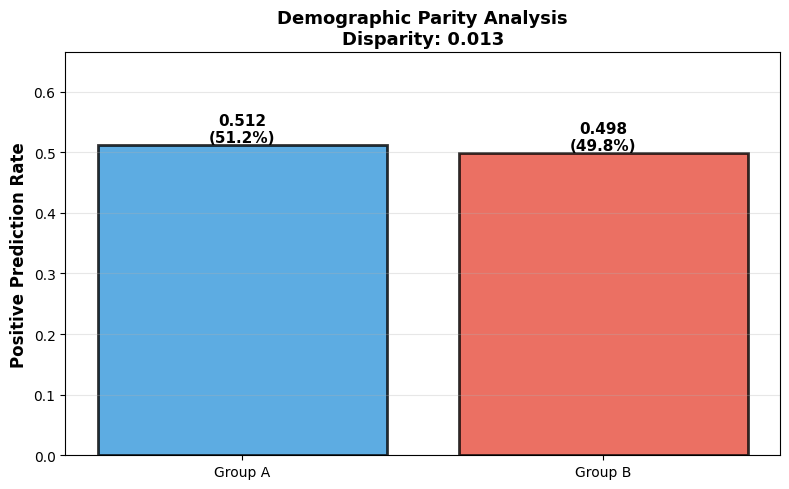

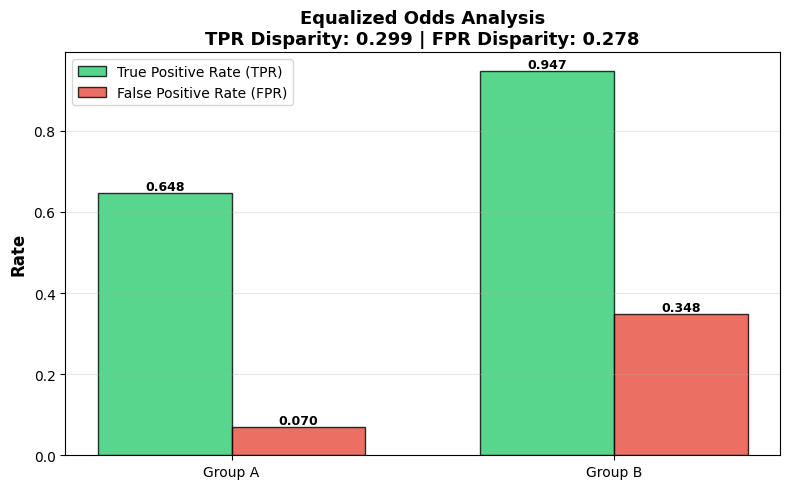

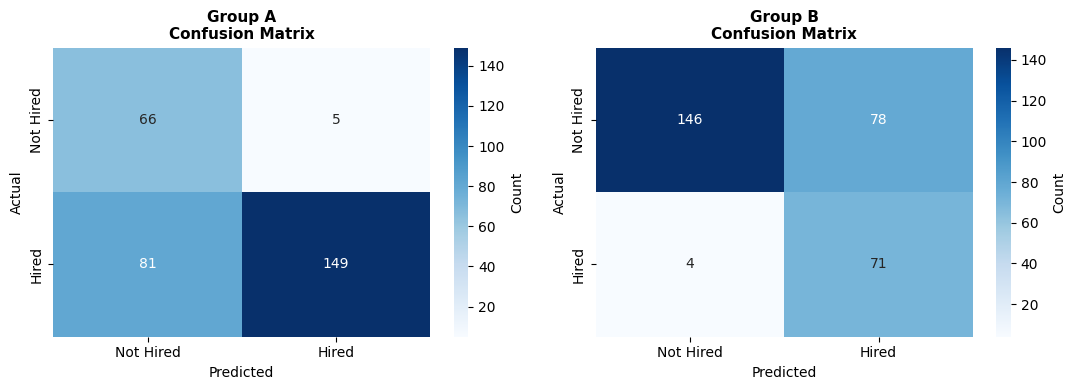

What the charts show: overall positive-prediction rates look similar
(demographic parity disparity only 0.013)...
...but the ERROR profiles differ sharply (TPR disparity 0.299,
FPR disparity 0.278) - see the confusion matrices.
This is exactly why we need MULTIPLE fairness metrics: a model can look
fair on demographic parity while failing equalized odds.


In [5]:
# Step 5: Visualize the bias detection results
# Three views: demographic parity, equalized odds, per-group confusion matrices

# --- Chart 1: Demographic parity ---
groups = list(parity_rates.keys())
rates = list(parity_rates.values())
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(groups, rates, color=['#3498db', '#e74c3c'], alpha=0.8,
              edgecolor='black', linewidth=2)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{rate:.3f}\n({rate*100:.1f}%)', ha='center', va='bottom',
            fontweight='bold', fontsize=11)
ax.set_ylabel('Positive Prediction Rate', fontsize=12, fontweight='bold')
ax.set_title(f'Demographic Parity Analysis\nDisparity: {parity_disparity:.3f}',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(rates) * 1.3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Chart 2: Equalized odds ---
tprs = [equalized_odds[g]['TPR'] for g in groups]
fprs = [equalized_odds[g]['FPR'] for g in groups]
x = np.arange(len(groups))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, tprs, width, label='True Positive Rate (TPR)',
            color='#2ecc71', alpha=0.8, edgecolor='black')
b2 = ax.bar(x + width/2, fprs, width, label='False Positive Rate (FPR)',
            color='#e74c3c', alpha=0.8, edgecolor='black')
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel('Rate', fontsize=12, fontweight='bold')
ax.set_title(f'Equalized Odds Analysis\nTPR Disparity: {tpr_disparity:.3f} | '
             f'FPR Disparity: {fpr_disparity:.3f}', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Chart 3: Confusion matrices by group ---
uniq = sorted(test_df['group'].unique())
fig, axes = plt.subplots(1, len(uniq), figsize=(11, 4))
for idx, group in enumerate(uniq):
    gd = test_df[test_df['group'] == group]
    cm = confusion_matrix(gd['hired'], gd['predicted'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{group}\nConfusion Matrix', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')
    axes[idx].set_xticklabels(['Not Hired', 'Hired'])
    axes[idx].set_yticklabels(['Not Hired', 'Hired'])
plt.tight_layout()
plt.show()

# Data-driven reading of the charts (computed, not assumed):
if parity_disparity > 0.1:
    print("What the charts show: the groups receive positive predictions at")
    print(f"clearly different rates (demographic parity disparity {parity_disparity:.3f}).")
else:
    print("What the charts show: overall positive-prediction rates look similar")
    print(f"(demographic parity disparity only {parity_disparity:.3f})...")
if tpr_disparity > 0.1 or fpr_disparity > 0.1:
    print(f"...but the ERROR profiles differ sharply (TPR disparity {tpr_disparity:.3f},")
    print(f"FPR disparity {fpr_disparity:.3f}) - see the confusion matrices.")
    print("This is exactly why we need MULTIPLE fairness metrics: a model can look")
    print("fair on demographic parity while failing equalized odds.")


## 🎯 Summary: What We Learned

**BEFORE this notebook**: We knew bias exists but didn't know how to detect it in our models.

**AFTER this notebook**: We can:
- ✅ Generate synthetic data with known bias for practice
- ✅ Calculate fairness metrics (demographic parity, equalized odds)
- ✅ Train ML models and detect bias in their predictions
- ✅ Visualize bias using charts and confusion matrices
- ✅ Interpret bias detection results
- ✅ Understand when to use different fairness metrics

### Key Takeaways

1. **Multiple Metrics Matter**: Different fairness metrics reveal different types of bias
2. **Demographic Parity vs. Equalized Odds**: They measure different aspects of fairness
3. **Bias Detection is Essential**: Must test for bias before and after model deployment
4. **Visualization Helps**: Charts make bias patterns easier to understand
5. **Systematic Approach**: Following a structured process ensures comprehensive bias detection

---

## 🚫 When Bias Detection Hits a Limitation

### The Limitation We Discovered

We've learned how to detect bias in AI systems using metrics like demographic parity and equalized odds. **But there's a critical problem:**

**We detected bias, but how do we fix it?**

Bias detection tells us:
- ✅ Where bias exists
- ✅ How severe the bias is
- ✅ Which groups are affected

**But it doesn't tell us:**
- ❌ How to **remove** the bias
- ❌ How to **mitigate** unfairness
- ❌ How to **fix** the model

### Why This Is a Problem

When we detect bias but can't fix it:
- We know there's a problem but can't solve it
- Unfair systems continue to operate
- Affected groups continue to be disadvantaged
- Detection alone isn't enough

### The Solution: Bias Mitigation

We need **bias mitigation techniques** to:
1. Remove bias from models
2. Make systems fairer across groups
3. Fix the problems we detected

**This is exactly what we'll learn in the next notebook: Bias Mitigation!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to detect bias using fairness metrics
- ✅ How to visualize bias patterns
- ✅ **The limitation**: Detection isn't enough - we need to fix it!

**Next notebook**: `02_bias_mitigation.ipynb`
- Learn how to mitigate bias using pre-processing, in-processing, and post-processing
- Fix the bias problems you detected
- Make models fairer across groups

**Congratulations!** 🎉 You've learned how to detect bias in machine learning models systematically!